# Match Prediciton - Pooled

In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel

import warnings
warnings.filterwarnings("ignore")

DATA_DIR = Path.cwd()
ADD_DIR = DATA_DIR.parent / "Additional"

matches = pd.read_parquet(DATA_DIR / "matches.parquet")
reg = pd.read_parquet(ADD_DIR / "for_regression.parquet")

print(f"Matches: {matches.shape}")
print(f"Regression file: {reg.shape}")

Matches: (3464, 36)
Regression file: (642410, 39)


In [8]:
# aggregate xG by match and team
match_xg = reg.groupby(['match_id', 'OFF_TEAM_ID']).agg(
    total_xg=('total_xg', 'sum'),
    total_shots=('n_shots', 'sum')
).reset_index()

teams_per_match = match_xg.groupby('match_id')['OFF_TEAM_ID'].count()
print(f"Matches with exactly 2 teams: {(teams_per_match == 2).sum()}")
print(f"Matches with != 2 teams: {(teams_per_match != 2).sum()}")

Matches with exactly 2 teams: 3446
Matches with != 2 teams: 14


In [9]:
# simpler approach - use groupby and aggregate directly
match_xg_pairs = match_xg[match_xg['match_id'].isin(
    teams_per_match[teams_per_match == 2].index
)].copy().sort_values(['match_id', 'OFF_TEAM_ID'])

def get_match_stats(group):
    group = group.reset_index(drop=True)
    return pd.Series({
        'team1_id': group.loc[0, 'OFF_TEAM_ID'],
        'team1_xg': group.loc[0, 'total_xg'],
        'team1_shots': group.loc[0, 'total_shots'],
        'team2_id': group.loc[1, 'OFF_TEAM_ID'],
        'team2_xg': group.loc[1, 'total_xg'],
        'team2_shots': group.loc[1, 'total_shots'],
    })

match_level = match_xg_pairs.groupby('match_id').apply(get_match_stats, include_groups=False)
match_level['xg_diff'] = match_level['team1_xg'] - match_level['team2_xg']

print(f"Match level shape: {match_level.shape}")
print(match_level.head(5).to_string())
print(f"\nxG differential stats:")
print(match_level['xg_diff'].describe())

Match level shape: (3446, 7)
          team1_id  team1_xg  team1_shots  team2_id  team2_xg  team2_shots   xg_diff
match_id                                                                            
7298         746.0  1.045777          8.0     971.0  2.972968         25.0 -1.927192
7430         759.0  0.948216          8.0     766.0  2.152028         17.0 -1.203813
7443         760.0  1.881383         13.0     765.0  3.843672         24.0 -1.962289
7444         761.0  0.580654          8.0     766.0  3.300426         37.0 -2.719773
7445         759.0  1.307833         10.0     767.0  0.700772          8.0  0.607061

xG differential stats:
count    3446.000000
mean        0.233975
std         1.392078
min        -6.431003
25%        -0.595648
50%         0.239451
75%         1.076322
max         6.333017
Name: xg_diff, dtype: float64


In [10]:
# get just what we need from matches parquet
match_meta = matches[['match_id', 'home_team_id', 'away_team_id', 'home_score', 'away_score']].copy()

# join to match_xg
match_xg_home = match_xg.merge(match_meta, left_on=['match_id', 'OFF_TEAM_ID'], right_on=['match_id', 'home_team_id'], how='inner')
match_xg_away = match_xg.merge(match_meta, left_on=['match_id', 'OFF_TEAM_ID'], right_on=['match_id', 'away_team_id'], how='inner')

match_xg_home = match_xg_home[['match_id', 'total_xg', 'total_shots', 'home_score', 'away_score']].rename(
    columns={'total_xg': 'home_xg', 'total_shots': 'home_shots'})
match_xg_away = match_xg_away[['match_id', 'total_xg', 'total_shots']].rename(
    columns={'total_xg': 'away_xg', 'total_shots': 'away_shots'})

match_final = match_xg_home.merge(match_xg_away, on='match_id')
match_final['xg_diff'] = match_final['home_xg'] - match_final['away_xg']
match_final['result'] = match_final.apply(lambda r:
    'home_win' if r['home_score'] > r['away_score']
    else 'away_win' if r['away_score'] > r['home_score']
    else 'draw', axis=1)

print(f"Shape: {match_final.shape}")
print(f"Nulls: {match_final.isnull().sum().sum()}")
print(f"\nResult distribution:")
print(match_final['result'].value_counts())
print(f"\nMean xG diff by result:")
print(match_final.groupby('result')['xg_diff'].mean().sort_values(ascending=False))

Shape: (3446, 9)
Nulls: 0

Result distribution:
result
home_win    1556
away_win    1096
draw         794
Name: count, dtype: int64

Mean xG diff by result:
result
home_win    1.034369
draw        0.167221
away_win   -0.701940
Name: xg_diff, dtype: float64


In [11]:
X = match_final[['xg_diff']].values
y = match_final['result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

# cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
print(f"\nCV Accuracy scores: {cv_scores}")
print(f"Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

              precision    recall  f1-score   support

    away_win       0.58      0.70      0.63       219
        draw       0.00      0.00      0.00       159
    home_win       0.64      0.87      0.74       312

    accuracy                           0.62       690
   macro avg       0.41      0.52      0.46       690
weighted avg       0.47      0.62      0.53       690


CV Accuracy scores: [0.58550725 0.62264151 0.61248186 0.59506531 0.59071118]
Mean: 0.6013 (+/- 0.0140)


In [12]:
X_multi = match_final[['xg_diff', 'home_xg', 'away_xg', 'home_shots', 'away_shots']].values

X_train, X_test, y_train, y_test = train_test_split(
    X_multi, y, test_size=0.2, random_state=42, stratify=y
)

model_multi = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
model_multi.fit(X_train, y_train)
y_pred_multi = model_multi.predict(X_test)

print(classification_report(y_test, y_pred_multi))

cv_scores_multi = cross_val_score(model_multi, X_multi, y, cv=cv, scoring='accuracy')
print(f"\nCV Accuracy: {cv_scores_multi.mean():.4f} (+/- {cv_scores_multi.std():.4f})")

              precision    recall  f1-score   support

    away_win       0.61      0.67      0.64       219
        draw       0.27      0.02      0.04       159
    home_win       0.63      0.88      0.73       312

    accuracy                           0.61       690
   macro avg       0.50      0.52      0.47       690
weighted avg       0.54      0.61      0.54       690


CV Accuracy: 0.6042 (+/- 0.0182)


In [13]:
# statsmodels multinomial logit for coefficients
X_sm = sm.add_constant(match_final[['xg_diff']])
# encode result as numeric
result_map = {'away_win': 0, 'draw': 1, 'home_win': 2}
y_sm = match_final['result'].map(result_map)

mnlogit = sm.MNLogit(y_sm, X_sm)
result_mn = mnlogit.fit()
print(result_mn.summary())

Optimization terminated successfully.
         Current function value: 0.877536
         Iterations 6
                          MNLogit Regression Results                          
Dep. Variable:                 result   No. Observations:                 3446
Model:                        MNLogit   Df Residuals:                     3442
Method:                           MLE   Df Model:                            2
Date:                Mon, 13 Apr 2026   Pseudo R-squ.:                  0.1734
Time:                        22:01:10   Log-Likelihood:                -3024.0
converged:                       True   LL-Null:                       -3658.2
Covariance Type:            nonrobust   LLR p-value:                3.722e-276
  result=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1333      0.051     -2.618      0.009      -0.233      -0.033
xg_diff        0.7339      0.

* model is highly significant. pseudo R^2 of 0.173 is pretty good for a match outcome model w/ single predictor. LLR p-value of 3.722e-276 confirms xG differential is useful predictor.

* The reference category is result=0 (away_win). So:

    * result=1 (draw) coefficient = 0.734 means a one-unit increase in xG differential increases the log-odds of a draw vs away win by 0.73
    * result=2 (home_win) coefficient = 1.422 means the same increase raises the log-odds of a home win vs away win by 1.42

* Both are highly significant (p is about 0.000) and the home win coeff being nearly 2x the draw coefficient makes sense as xG differential is a stronger signal for wins than for draws

[0, 1, 2]
          0         1         2
0  0.952043  0.044246  0.003711
1  0.949049  0.046801  0.004150
2  0.945866  0.049494  0.004640
3  0.942484  0.052330  0.005186
4  0.938889  0.055316  0.005795


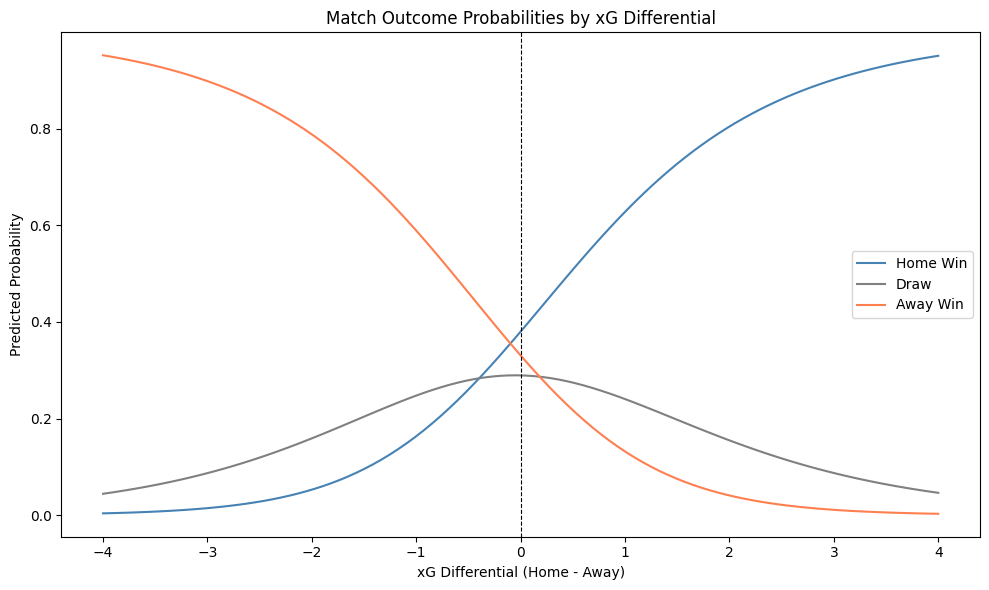

In [14]:
xg_range = np.linspace(-4, 4, 100)
X_plot = sm.add_constant(pd.DataFrame({'xg_diff': xg_range}))
probs = result_mn.predict(X_plot)

print(probs.columns.tolist())  # check column names first
print(probs.head())

plt.figure(figsize=(10, 6))
plt.plot(xg_range, probs[2], label='Home Win', color='steelblue')
plt.plot(xg_range, probs[1], label='Draw', color='gray')
plt.plot(xg_range, probs[0], label='Away Win', color='coral')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.xlabel('xG Differential (Home - Away)')
plt.ylabel('Predicted Probability')
plt.title('Match Outcome Probabilities by xG Differential')
plt.legend()
plt.tight_layout()
plt.show()

**Summary: Multinomial logistic regression predicting match outcome (home win / draw / away win) from actual xG differential (home team xG minus away team xG), across 3,446 matches.**

Highlights:

* xG differential is a strong predictor of match outcomes, w/ a pseudo R^2 of 0.173 w/ a single feature, highly significant (p ~ 0)
* @ xG differential of 0, the predicted probs are approx. 35% home win, 30% draw, 35% away win.
* A +1 xG differential in favor of the home team increases home win log-odds by 1.42 relative to away win
* Draw prob. peaks near zero xG differential and decreases as match becomes more one-sided
* Draws are tough to predict. Recall of 0.01 in classification.

Model performance stats:

* 60% accuracy on test set, CV mean of 0.601 (std 0.013). This is fairly stable and consistent.
* Naive baseline of always predicting home win would yield around a 45% accuracy, so the model does add some predictive value

Notes:

* This model uses actual observed xG. Next step is replacing observed xG with predicted xG from our possession-level regression models to build lineup-based predictions
* Home/away team alignment was verified using the StatsBomb matches.parquet file
* 14 matches with incomplete lineup data were excluded, leaving 3,446 of 3,460 matched matches (very small percentage)
* The model uses xG aggregated at the possession level from possession-level for_regression.parquet file